In [1]:
import cv2
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
cv2.__version__

'4.12.0'

In [4]:
cap = cv2.VideoCapture(0)
for i in range(int(100)):
    success,image = cap.read() 
if success:
    print(-1)
cap.release()

2026-02-07 13:42:08.884 python[49690:11513281] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


-1


In [ ]:
RAW

In [5]:
success

True

In [6]:
image.shape

(1080, 1920, 3)

In [7]:
image.dtype

dtype('uint8')

In [7]:
1080*1920*3

6220800

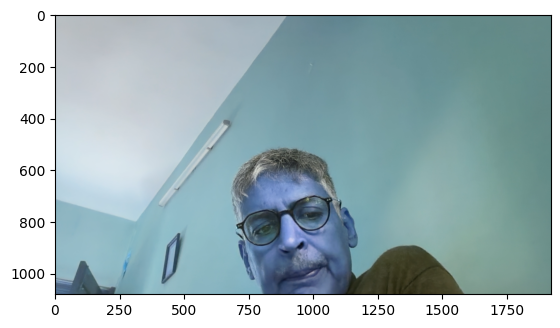

In [8]:
plt.imshow(image)

In [9]:
cv2.imwrite('/Users/rsingh/Downloads/test.png', np.array(image))
cv2.imwrite('/Users/rsingh/Downloads/test.jpg', np.array(image))

True

In [10]:
JPEG = cv2.imread('/Users/rsingh/Downloads/test.jpg')

In [11]:
PNG = cv2.imread('/Users/rsingh/Downloads/test.png')

In [12]:
JPEG = cv2.cvtColor(JPEG,cv2.COLOR_BGR2RGB)
PNG = cv2.cvtColor(PNG,cv2.COLOR_BGR2RGB)

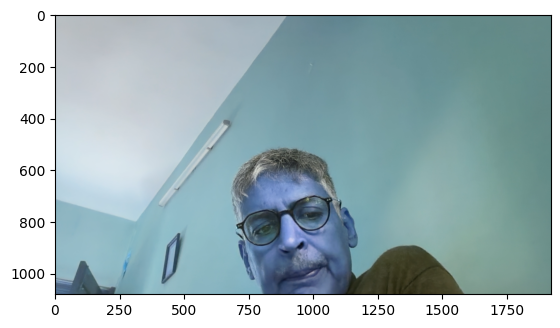

In [13]:
plt.imshow(image)

In [15]:
image[0,100]

array([184, 188, 192], dtype=uint8)

In [16]:
cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

array([[[194, 191, 184],
        [194, 191, 184],
        [194, 191, 184],
        ...,
        [137, 138, 101],
        [135, 137, 100],
        [137, 138, 101]],

       [[193, 189, 183],
        [193, 189, 183],
        [194, 191, 184],
        ...,
        [137, 138, 101],
        [137, 138, 101],
        [137, 138, 101]],

       [[193, 189, 183],
        [193, 189, 183],
        [194, 190, 186],
        ...,
        [137, 138, 101],
        [137, 138, 101],
        [137, 138, 101]],

       ...,

       [[133, 103,  83],
        [133, 104,  81],
        [133, 104,  81],
        ...,
        [135, 141, 110],
        [135, 141, 110],
        [135, 141, 110]],

       [[134, 105,  84],
        [134, 105,  82],
        [134, 105,  82],
        ...,
        [135, 141, 110],
        [135, 141, 110],
        [135, 141, 110]],

       [[137, 107,  86],
        [135, 106,  83],
        [135, 106,  83],
        ...,
        [135, 141, 110],
        [135, 141, 110],
        [135, 141, 110]]

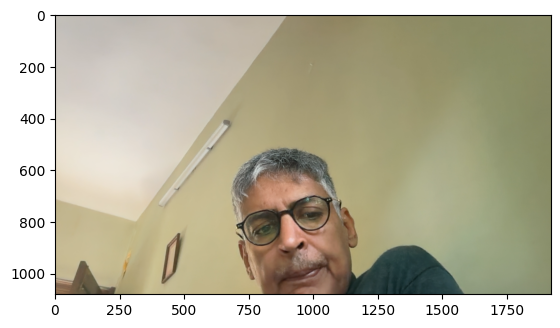

In [17]:
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))

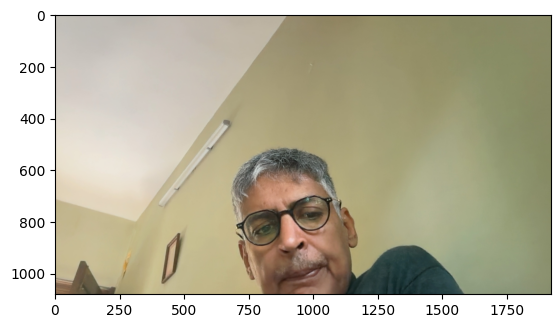

In [18]:
plt.imshow(JPEG)

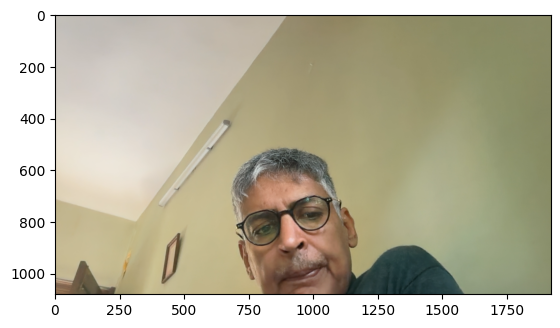

In [19]:
plt.imshow(PNG)

In [20]:
image.shape

(1080, 1920, 3)

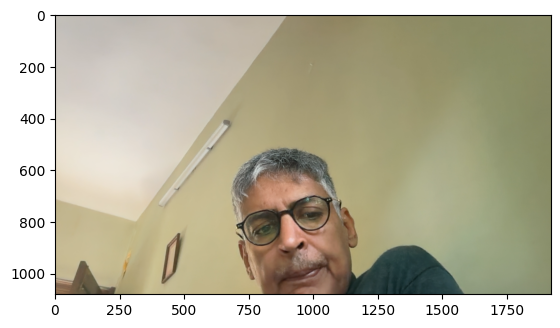

In [21]:
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image)

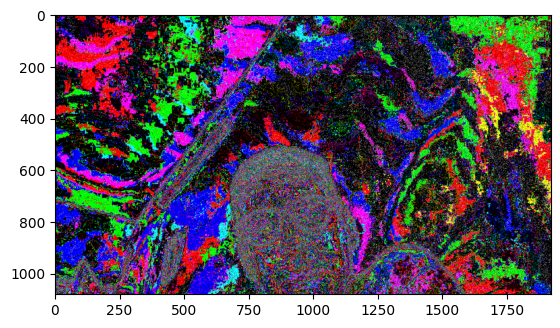

In [22]:
plt.imshow(JPEG-image)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-18.0..10.0].


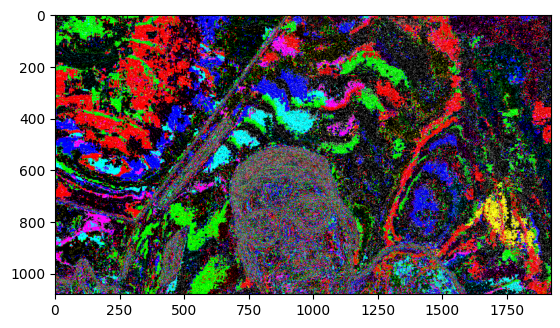

In [23]:
plt.imshow(JPEG.astype('float')-image.astype('float'))

In [24]:
MSE = np.mean((JPEG.astype('float')-image.astype('float'))**2)
MSE

np.float64(0.8879959169238684)

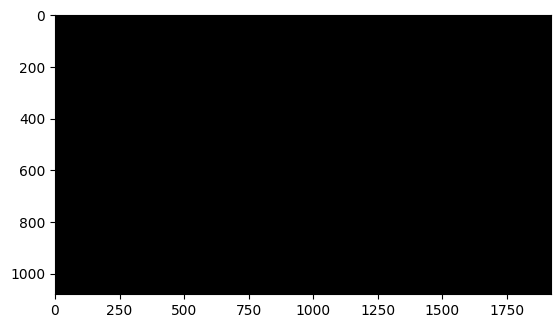

In [25]:
plt.imshow(PNG-image)

In [26]:
np.mean((PNG.astype('float')-image.astype('float'))**2)

np.float64(0.0)

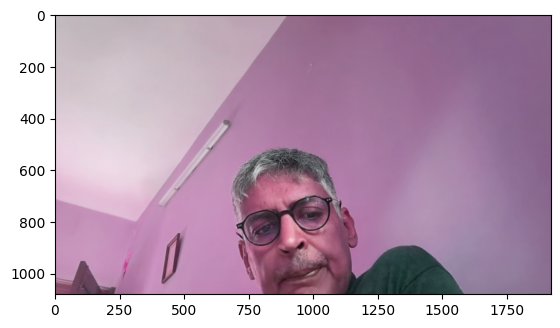

In [27]:
plt.imshow(image[:,:,(0,2,1)])

In [28]:
def create_infrared_effect(img):
    """
    Applies a false-color infrared effect to an image.

    Args:
        image_path (str): The path to the input image.

    Returns:
        numpy.ndarray: The image with the infrared effect applied.
    """
    # Load the image
#     img = cv2.imread(image_path)
#     if img is None:
#         print(f"Error: Could not load image from {image_path}")
#         return None
    #img = img[100:-100,100:-100,:]
    # Split the image into its BGR channels
    r, g, b = cv2.split(img)

    # Simulate the IR effect by swapping and manipulating channels
    # A common approach for false color IR:
    # - Red channel becomes the original Green channel (or a modified version)
    # - Green channel becomes the original Red channel (or a modified version)
    # - Blue channel becomes a darkened version of the original Blue channel
    
    # For a classic Aerochrome-like effect, you might swap red and blue,
    # and enhance the green.
    # Here's one popular method:
    # New Red = Original Green
    # New Green = Original Red
    # New Blue = Original Blue * 0.5 (to darken the sky/water)

    # Create the new channels
    new_r = g.copy() # Green channel becomes the new Red
    new_g = r.copy() # Red channel becomes the new Green
    new_b = (b * 0.5).astype(np.uint8) # Darken the Blue channel

    # Merge the new channels to create the false-color IR image
    infrared_img = cv2.merge([new_b, new_g, new_r])

    return infrared_img

In [29]:
orig = image

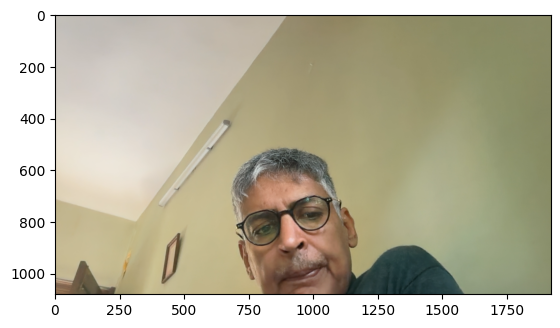

In [30]:
plt.imshow(orig)

In [31]:
IR = create_infrared_effect(orig)

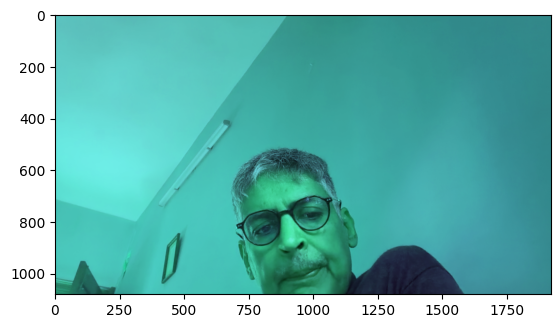

In [32]:
plt.imshow(IR)

(array([   7930.,  104834.,  226653.,  312654.,  848575., 1495174.,
        1267759., 1313388.,  569115.,   74718.]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

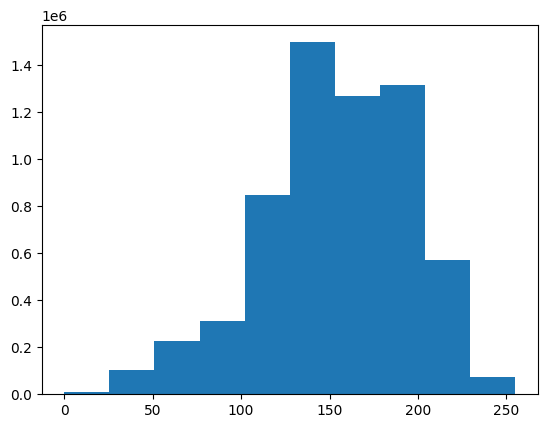

In [39]:
plt.hist(orig.reshape(-1))

(array([  43954.,  394183., 1322984.,  502336.,  220278., 1005986.,
        1174353., 1013257.,  468752.,   74717.]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

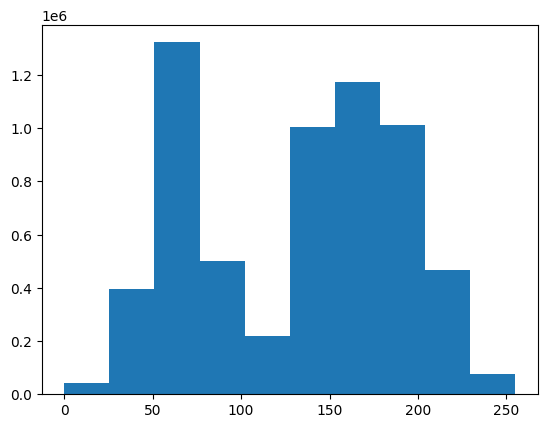

In [33]:
plt.hist(IR.reshape(-1))

(array([2.48000e+03, 3.74190e+04, 7.55910e+04, 7.31730e+04, 5.47210e+04,
        5.94794e+05, 5.55715e+05, 4.78742e+05, 2.00679e+05, 2.86000e+02]),
 array([  9. ,  33.6,  58.2,  82.8, 107.4, 132. , 156.6, 181.2, 205.8,
        230.4, 255. ]),
 <BarContainer object of 10 artists>)

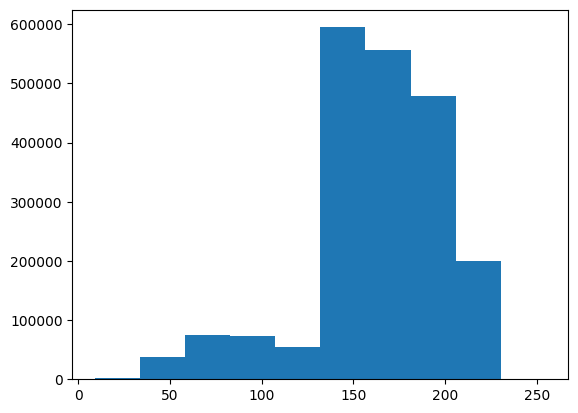

In [36]:
plt.hist(IR[:,:,2].reshape(-1))

In [37]:
orig

array([[[194, 191, 184],
        [194, 191, 184],
        [194, 191, 184],
        ...,
        [137, 138, 101],
        [135, 137, 100],
        [137, 138, 101]],

       [[193, 189, 183],
        [193, 189, 183],
        [194, 191, 184],
        ...,
        [137, 138, 101],
        [137, 138, 101],
        [137, 138, 101]],

       [[193, 189, 183],
        [193, 189, 183],
        [194, 190, 186],
        ...,
        [137, 138, 101],
        [137, 138, 101],
        [137, 138, 101]],

       ...,

       [[133, 103,  83],
        [133, 104,  81],
        [133, 104,  81],
        ...,
        [135, 141, 110],
        [135, 141, 110],
        [135, 141, 110]],

       [[134, 105,  84],
        [134, 105,  82],
        [134, 105,  82],
        ...,
        [135, 141, 110],
        [135, 141, 110],
        [135, 141, 110]],

       [[137, 107,  86],
        [135, 106,  83],
        [135, 106,  83],
        ...,
        [135, 141, 110],
        [135, 141, 110],
        [135, 141, 110]]

In [44]:
reduced_res = orig[::30,::30,:]

In [45]:
a = [1,2,3,4,6,7,8]
a[::3]

[1, 4, 8]

In [46]:
reduced_res.shape

(36, 64, 3)

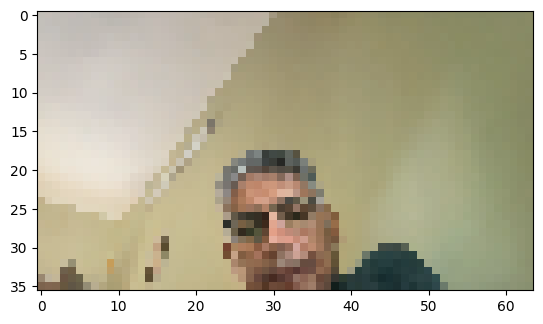

In [47]:
plt.imshow(reduced_res)

In [48]:
cv2.imwrite('/Users/rsingh/Downloads/test.png', np.array(reduced_res))


True

In [68]:
a=[1,2,3,4,5]
a[::2]

[1, 3, 5]

In [60]:
IR.shape

(880, 1720, 3)

In [49]:
IR2 = cv2.resize(IR,(None,None),fx=1/4,fy=1/4,interpolation = cv2.INTER_NEAREST)

In [50]:
IR3 = cv2.resize(IR,(1920,1080),interpolation = cv2.INTER_LINEAR)

In [51]:
IR4 = cv2.resize(IR,(1920,1080),interpolation = cv2.INTER_CUBIC)

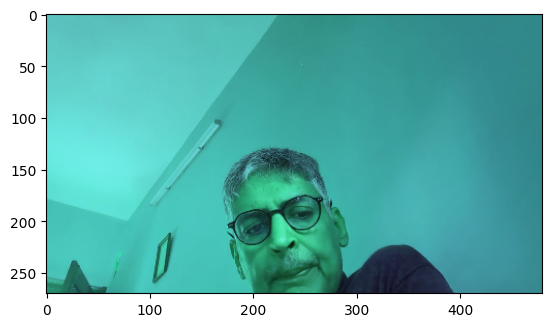

In [52]:
plt.imshow(IR2)

In [53]:
IR.shape

(1080, 1920, 3)

In [54]:
IR2.shape

(270, 480, 3)

In [55]:
plt.imshow(IR2-IR3)

ValueError: operands could not be broadcast together with shapes (270,480,3) (1080,1920,3) 

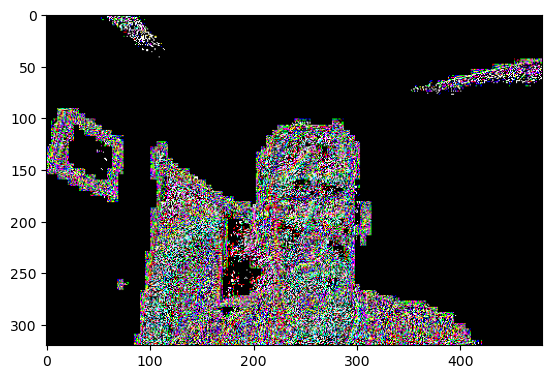

In [55]:
plt.imshow(IR1-IR4)

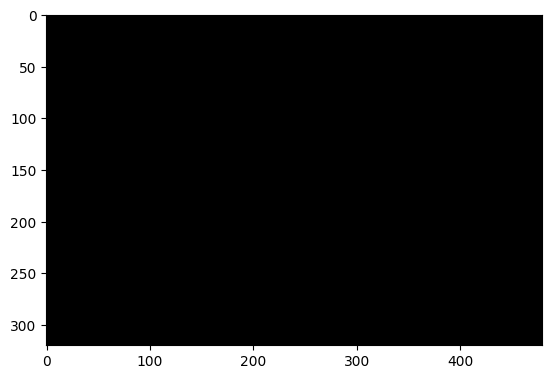

In [32]:
plt.imshow(IR3-IR4)

(1080, 1920)

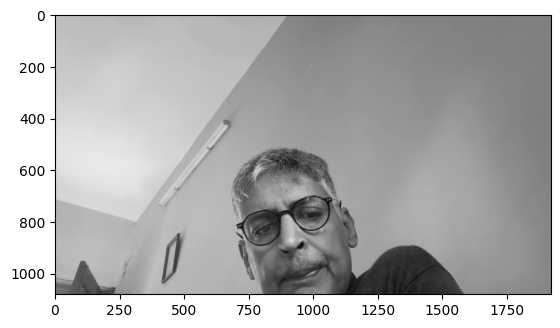

In [61]:
gray = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)

plt.imshow(gray,cmap='gray')
gray.shape

(array([  3942.,  56298.,  48304.,  66505.,  63280., 656450., 478457.,
        464143., 213335.,  22886.]),
 array([0.04365079, 0.13928571, 0.23492063, 0.33055556, 0.42619048,
        0.5218254 , 0.61746032, 0.71309524, 0.80873016, 0.90436508,
        1.        ]),
 <BarContainer object of 10 artists>)

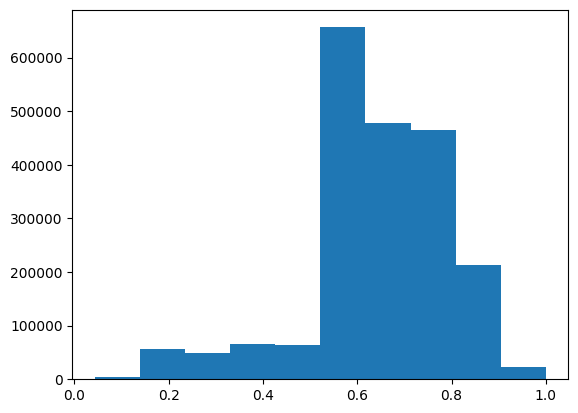

In [62]:
plt.hist(gray.reshape(-1)/np.max(gray))

In [63]:
gray.shape
np.max(gray)

np.uint8(252)

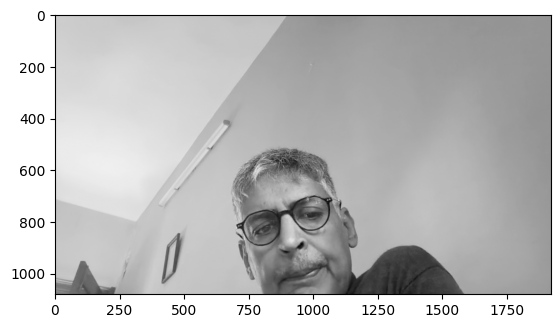

In [66]:

gray = gray/np.max(gray)

log_gray = np.log(1+gray)
log_gray -= np.min(log_gray)
log_gray /= np.max(log_gray)
plt.imshow(log_gray,cmap='gray')

(array([   984.,  18700.,  57248.,  46869.,  64130., 209014., 677838.,
        614433., 312170.,  72214.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

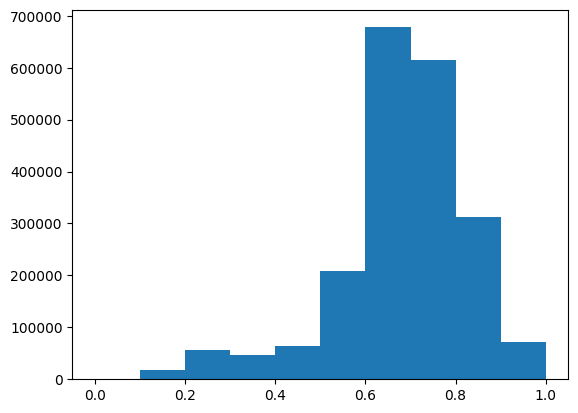

In [71]:
plt.hist(log_gray.reshape(-1))

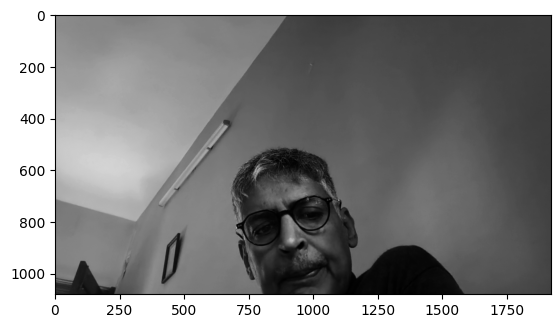

In [75]:
powerlaw_gray = gray**(2.2)
powerlaw_gray -= np.min(powerlaw_gray)
powerlaw_gray /= np.max(powerlaw_gray)
plt.imshow(powerlaw_gray,cmap='gray')

(array([1.40000e+02, 2.12900e+03, 1.74150e+04, 5.53680e+04, 4.58090e+04,
        6.95660e+04, 3.86471e+05, 7.45209e+05, 6.02136e+05, 1.49357e+05]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

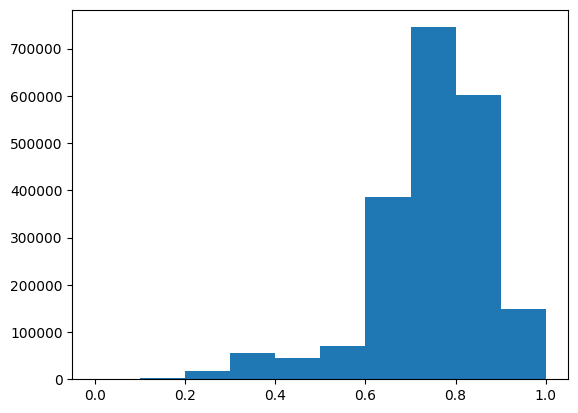

In [70]:
plt.hist(powerlaw_gray.reshape(-1))

In [33]:
IR1 = IR1[8:,8:] #crop

(312, 472, 3)


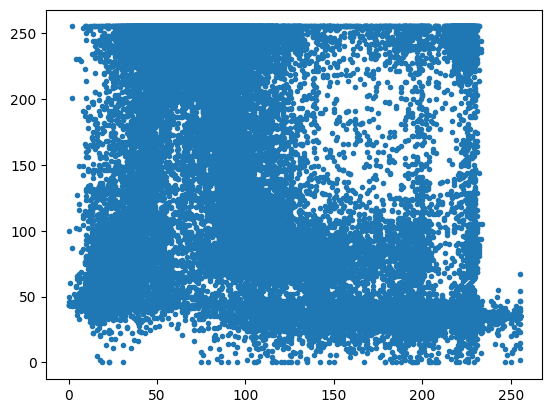

In [34]:
print(IR1.shape)
plt.plot(orig[:,:,0][::-1].flatten(),IR1[:,:,0][::-1].flatten(),'.')

In [35]:
np.mean(IR1,axis=(0,1))

array([ 70.95592949,  83.05185925, 198.45314537])

In [36]:
np.mean(orig,axis=(0,1))

array([167.47060381, 175.50125625, 179.98402868])

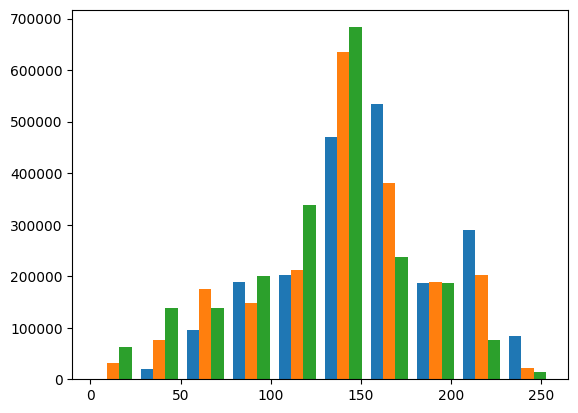

In [41]:
_=plt.hist(orig.reshape(-1,3))

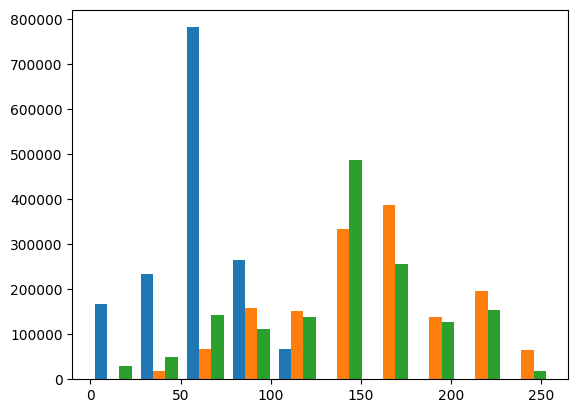

In [43]:
_=plt.hist(IR.reshape(-1,3))

In [81]:
import matplotlib.cm as mtpltcm
import matplotlib

In [82]:
colormap = mtpltcm.jet_r

In [83]:
cNorm = matplotlib.colors.Normalize(vmin=0, vmax=255)

In [84]:
scalarMap = mtpltcm.ScalarMappable(norm=cNorm, cmap=colormap)

In [85]:
grayOrig = cv2.cvtColor(orig,cv2.COLOR_BGR2GRAY)

In [86]:
grayOrig

array([[235, 236, 236, ..., 107, 107, 107],
       [236, 236, 236, ..., 107, 107, 107],
       [237, 237, 237, ..., 107, 107, 107],
       ...,
       [ 53,  55,  56, ..., 118, 118, 118],
       [ 53,  53,  56, ..., 118, 117, 118],
       [ 52,  53,  56, ..., 118, 118, 118]],
      shape=(1080, 1920), dtype=uint8)

In [87]:
colors = scalarMap.to_rgba(grayOrig)

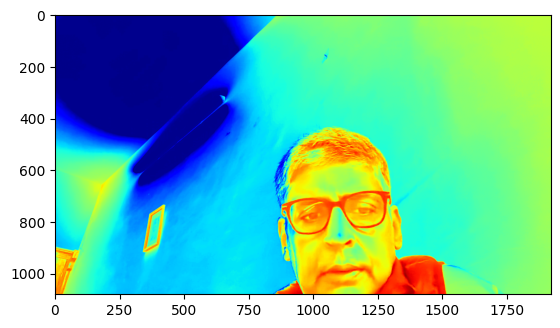

In [88]:
plt.imshow(colors)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000004].


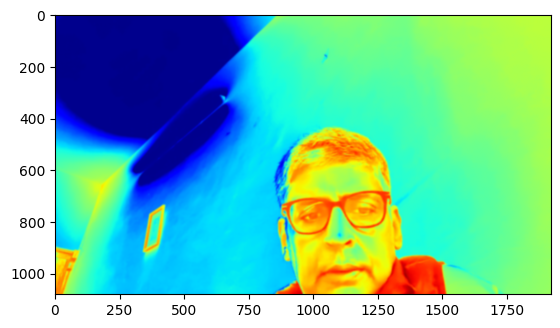

In [89]:
plt.imshow(cv2.GaussianBlur(colors,(15,15),0))

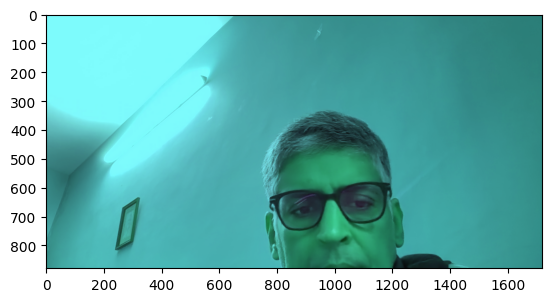

In [90]:
plt.imshow(IR)

In [69]:
grayOrig = cv2.cvtColor(orig,cv2.COLOR_BGR2GRAY)

In [70]:
grayOrig

array([[129, 130, 130, ..., 106, 116, 128],
       [129, 130, 131, ...,  97, 103, 117],
       [130, 131, 132, ...,  97, 102, 112],
       ...,
       [120, 120, 121, ...,  53,  54,  54],
       [121, 120, 120, ...,  53,  53,  53],
       [120, 119, 119, ...,  51,  52,  52]],
      shape=(1080, 1920), dtype=uint8)

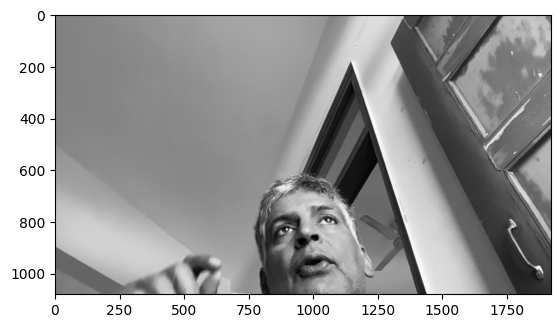

In [71]:
plt.imshow(grayOrig)
plt.set_cmap('gray')

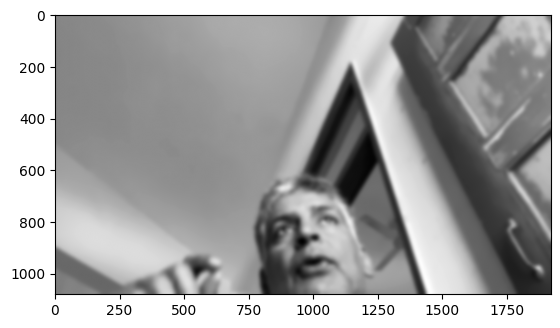

In [75]:
plt.imshow(cv2.GaussianBlur(grayOrig,(45,45),0))
plt.set_cmap('gray')

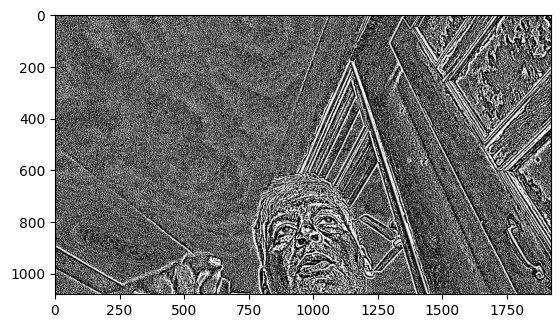

In [73]:
plt.imshow(cv2.GaussianBlur(grayOrig,(15,15),0)-grayOrig)
plt.set_cmap('gray')

In [74]:
cv2.GaussianBlur(grayOrig,(15,15),0)-grayOrig

array([[  2,   1,   1, ..., 254, 244, 232],
       [  2,   1,   0, ...,   7,   1, 243],
       [  1,   0, 255, ...,   8,   3, 249],
       ...,
       [  0,   0, 255, ..., 255, 254, 254],
       [255,   0,   0, ..., 255, 255, 255],
       [  0,   1,   1, ...,   1,   0,   0]],
      shape=(1080, 1920), dtype=uint8)

In [54]:
cv2.GaussianBlur(grayOrig,(15,15),0).astype('int')-grayOrig.astype('int')

array([[-3, -5, -3, ...,  2,  2,  2],
       [ 8, -1, -6, ...,  1,  1,  1],
       [35, 18,  1, ...,  0,  0,  0],
       ...,
       [ 2,  1,  0, ...,  2,  2,  0],
       [ 1,  1,  0, ...,  3,  2, -1],
       [ 2,  1,  0, ...,  4,  2, -1]])

In [55]:
unsharpMask = cv2.GaussianBlur(grayOrig,(15,15),0).astype('int')-grayOrig.astype('int')

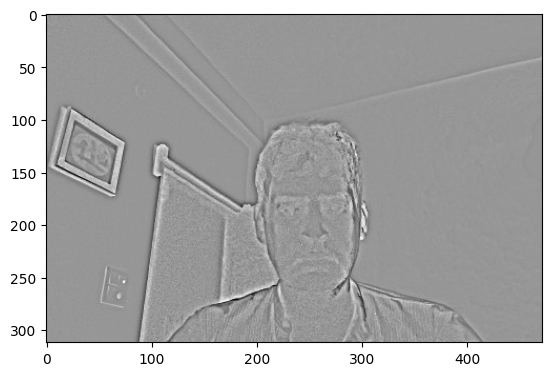

In [56]:
plt.imshow(unsharpMask)

In [57]:
unsharpMask[unsharpMask<0] = 0
unsharpMask[unsharpMask>255] = 255

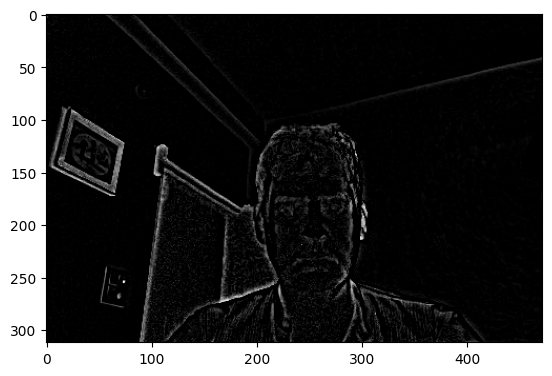

In [59]:
plt.imshow(unsharpMask.astype('uint8'))

In [60]:
gaussian_3 = cv2.GaussianBlur(grayOrig,(15,15),0)
unsharp_image = cv2.addWeighted(grayOrig, 2.5, gaussian_3, -1.5, 0)

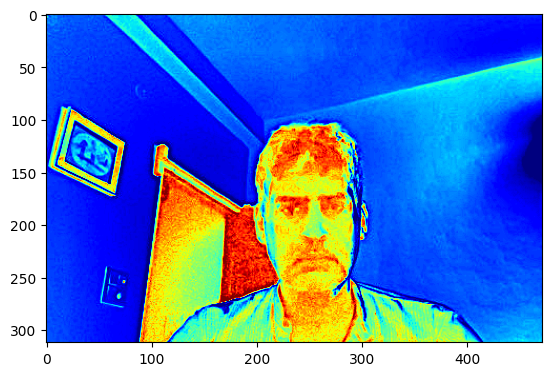

In [61]:

plt.imshow(unsharp_image)
colors = scalarMap.to_rgba(unsharp_image)
plt.set_cmap('jet_r')

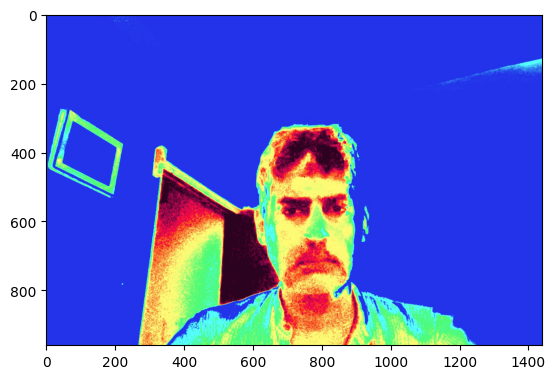

In [62]:
plt.imshow(IR)

In [59]:
unsharpMask

array([[ 0,  0,  0, ...,  2,  2,  2],
       [ 8,  0,  0, ...,  1,  1,  1],
       [35, 18,  1, ...,  0,  0,  0],
       ...,
       [ 2,  1,  0, ...,  2,  2,  0],
       [ 1,  1,  0, ...,  3,  2,  0],
       [ 2,  1,  0, ...,  4,  2,  0]])

hsv = cv2.cvtColor(orig, cv2.COLOR_BGR2HSV)


plt.imshow(hsv)

mask = cv2.inRange(hsv, (0, 75, 40), (180, 255, 255))


mask_3d = np.repeat(mask[:, :, np.newaxis], 3, axis=2)


blurred_frame = cv2.GaussianBlur(orig, (25, 25), 0)


frame = np.where(mask_3d == (255, 255, 255), orig, blurred_frame)

plt.imshow(frame)

In [72]:
angle = 30/180*np.pi

rotation_matrix = np.asarray([[np.cos(angle),-np.sin(angle)],[np.sin(angle),np.cos(angle)]])
new_img = np.zeros_like(orig)

In [73]:
pivot_row = 0
pivot_col = 0
for row in range(orig.shape[0]):
    for col in range(orig.shape[1]):
        rowcol_mat = np.array([row-pivot_row,col-pivot_col])
        rotate = np.dot(rotation_matrix,rowcol_mat)
        new_row = pivot_row+int(rotate[0])
        new_col = pivot_col+int(rotate[1])
        if new_row>0 and new_row<orig.shape[0] and new_col>0 and new_col<orig.shape[1]:
            new_img[new_row,new_col,:] = orig[row,col,:]

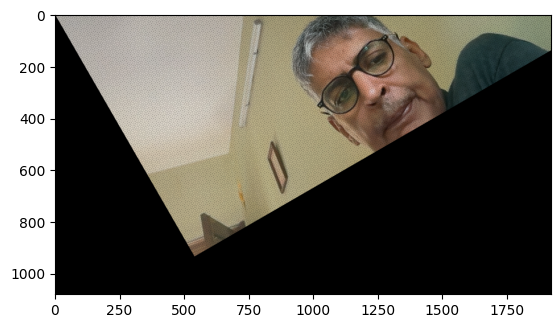

In [74]:
plt.imshow(new_img)

# 